# Reporte de entrenamiento: Conversión de Celsius a Fahrenheit

Este notebook presenta un ejemplo completo de entrenamiento con una red neuronal `MLPRegressor` para aprender la relación entre grados Celsius y Fahrenheit.

El objetivo es mostrar el proceso de entrenamiento, los resultados obtenidos y las gráficas necesarias para presentar el comportamiento del modelo de forma profesional.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="talk")

In [2]:
# Dataset sintético para el reporte
celsius = np.linspace(-40, 120, 120).reshape(-1, 1)
fahrenheit = (celsius * 9 / 5 + 32).ravel()

datos = pd.DataFrame({
    "Celsius": celsius.ravel(),
    "Fahrenheit": fahrenheit,
})

display(datos.head(10))
print(f"Registros creados: {len(datos)}")
print(f"Rango Celsius: {datos['Celsius'].min():.1f} a {datos['Celsius'].max():.1f}")

,Celsius,Fahrenheit
0,-40.000000,-40.000000
1,-38.655462,-37.579832
2,-37.310924,-35.159664
3,-35.966387,-32.739496
4,-34.621849,-30.319328
5,-33.277311,-27.899160
6,-31.932773,-25.478992
7,-30.588235,-23.058824
8,-29.243697,-20.638655
9,-27.899160,-18.218487


Registros creados: 120
Rango Celsius: -40.0 a 120.0


## 1. Datos y preparación

Se utiliza un conjunto sintético de pares Celsius-Fahrenheit para entrenar y evaluar el modelo.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    celsius,
    fahrenheit,
    test_size=0.2,
    random_state=42,
)

modelo = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "mlp",
            MLPRegressor(
                hidden_layer_sizes=(8,),
                activation="identity",
                solver="adam",
                learning_rate_init=0.01,
                max_iter=1500,
                random_state=42,
            ),
        ),
    ]
)

modelo.fit(X_train, y_train)

mlp = modelo.named_steps["mlp"]
print(f"Iteraciones de entrenamiento: {mlp.n_iter_}")
print(f"Pérdida final: {mlp.loss_:.6f}")

Iteraciones de entrenamiento: 560
Pérdida final: 0.001541


## 2. Entrenamiento del modelo

La red neuronal se entrena con una partición de entrenamiento y validación para poder medir su desempeño de forma más clara.

In [5]:
# Predicciones sobre el conjunto de prueba

y_pred = modelo.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
metricas = {
    "MAE": mean_absolute_error(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": rmse,
    "R2": r2_score(y_test, y_pred),
}

print("Métricas del modelo:")
for nombre, valor in metricas.items():
    print(f"{nombre}: {valor:.6f}")

resultados = pd.DataFrame(
    {
        "Celsius": X_test.ravel(),
        "Fahrenheit real": y_test,
        "Fahrenheit predicho": y_pred,
        "Error": y_test - y_pred,
    }
).sort_values("Celsius")

display(resultados.head(12))

Métricas del modelo:
MAE: 0.048142
MSE: 0.003241
RMSE: 0.056927
R2: 0.999999


,Celsius,Fahrenheit real,Fahrenheit predicho,Error
17,-40.000000,-40.000000,-40.100994,0.100994
2,-34.621849,-30.319328,-30.416238,0.096911
7,-26.554622,-15.798319,-15.889105,0.090786
12,-25.210084,-13.378151,-13.467917,0.089765
10,-15.798319,3.563025,3.480405,0.082620
4,-5.042017,22.924370,22.849916,0.074454
22,1.680672,35.025210,34.955860,0.069350
13,8.403361,47.126050,47.061805,0.064246
8,13.781513,56.806723,56.746560,0.060163
0,19.159664,66.487395,66.431316,0.056079


## 3. Evaluación y resultados

En esta sección se comparan las predicciones del modelo con los valores reales y se resumen las métricas principales.

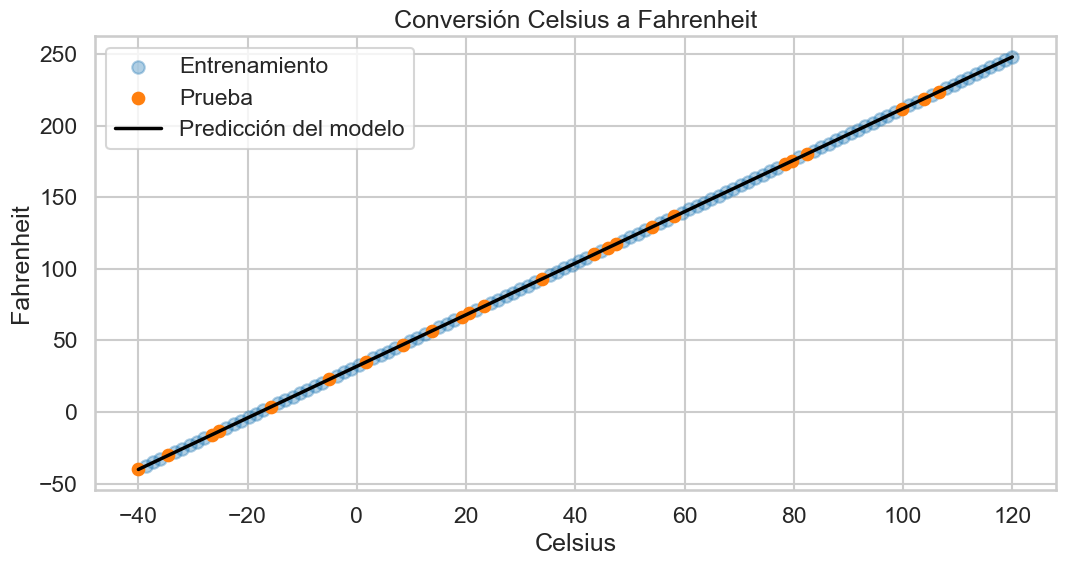

In [6]:
# Gráfica de valores reales vs predicciones

x_linea = np.linspace(celsius.min(), celsius.max(), 200).reshape(-1, 1)
y_linea = modelo.predict(x_linea)

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(X_train, y_train, alpha=0.35, label="Entrenamiento", color="tab:blue")
ax.scatter(X_test, y_test, label="Prueba", color="tab:orange", s=70)
ax.plot(x_linea, y_linea, color="black", linewidth=2.5, label="Predicción del modelo")
ax.set_title("Conversión Celsius a Fahrenheit")
ax.set_xlabel("Celsius")
ax.set_ylabel("Fahrenheit")
ax.legend()
plt.tight_layout()
plt.show()

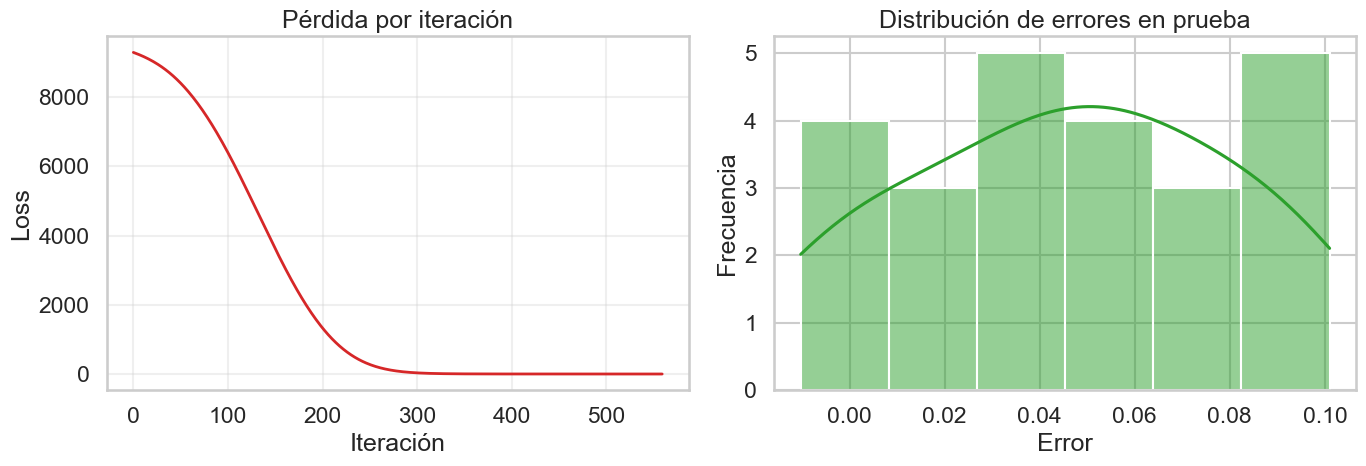

Resumen final del entrenamiento:
MAE  = 0.048142
RMSE = 0.056927
R2   = 0.999999


In [7]:
# Curva de entrenamiento y análisis de residuos

loss_curve = mlp.loss_curve_
residuos = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(loss_curve, color="tab:red", linewidth=2)
axes[0].set_title("Pérdida por iteración")
axes[0].set_xlabel("Iteración")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

sns.histplot(residuos, kde=True, ax=axes[1], color="tab:green")
axes[1].set_title("Distribución de errores en prueba")
axes[1].set_xlabel("Error")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

print("Resumen final del entrenamiento:")
print(f"MAE  = {metricas['MAE']:.6f}")
print(f"RMSE = {metricas['RMSE']:.6f}")
print(f"R2   = {metricas['R2']:.6f}")

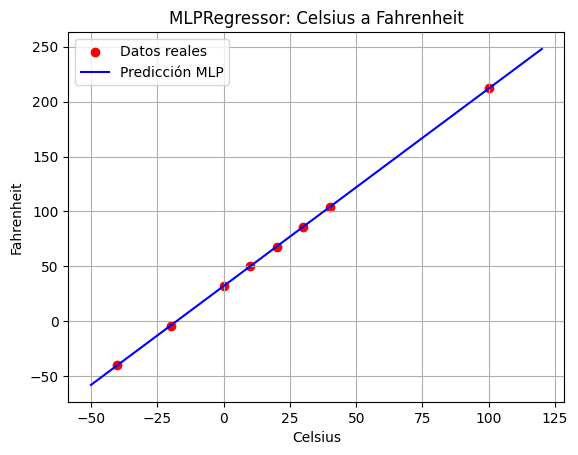

Coeficientes aprendidos: [array([[0.45462378]]), array([[3.95931778]])]
Bias aprendidos: [array([6.86568973]), array([4.81654905])]


In [ ]:
## 4. Conclusión

El modelo aprende la conversión Celsius-Fahrenheit con métricas muy bajas de error, lo que confirma que la relación fue capturada correctamente.

Como siguiente paso, se puede cambiar el problema a un caso con datos reales, ruido o más variables de entrada para obtener un entrenamiento más representativo de un proyecto de IA completo.